In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.llm_api.client import GPT4AllClient, GPT4AllMessage
import pandas as pd
from utils.pipeline import run_pipeline
from utils.evaluation import evaluate_metrics
import os, io
from utils.pipeline import run_pipeline
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import json
from sklearn.cluster import KMeans
import scipy.stats as stats

/home/dnumicmesa/miniconda3/envs/NLP/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/dnumicmesa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/dnumicmesa/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt to /home/dnumicmesa/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


### Loading map of Europe

In [3]:
## load map from shapefile
world_gdf = gpd.read_file('data/europe/CNTR_RG_20M_2024_3035.shp')
world_gdf = world_gdf.to_crs(epsg=4326)
europe_gdf = world_gdf[world_gdf['EU_STAT'] == 'T']
europe_gdf.loc[78, 'geometry'] = world_gdf[
    world_gdf['CNTR_ID'] == 'FR'
].iloc[0].geometry.geoms[3] ## dropping France's overseas teritories

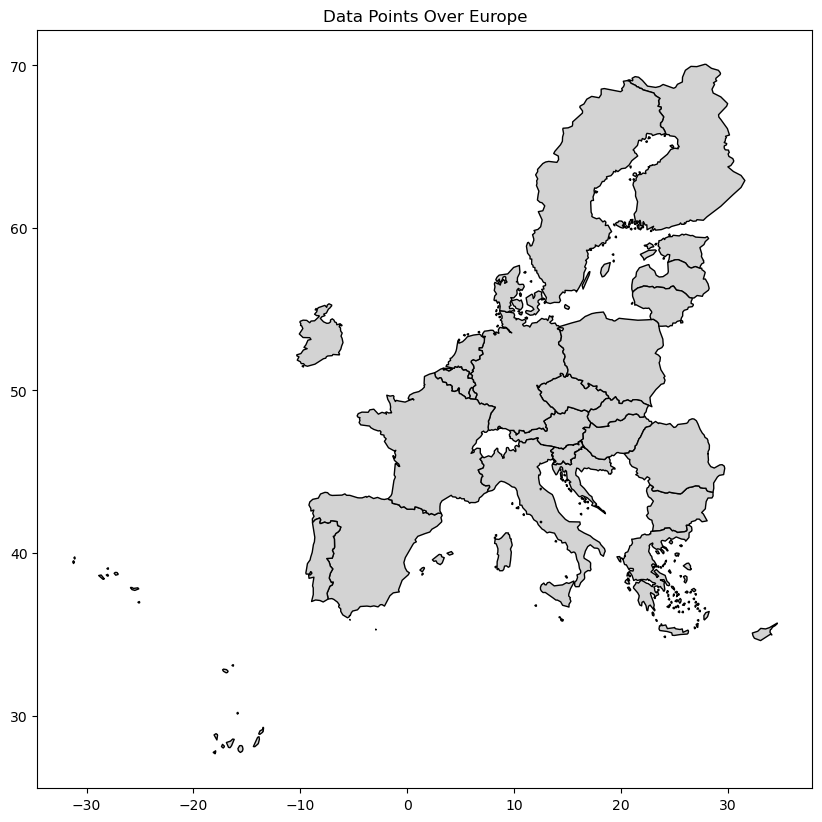

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray') 
plt.title("Data Points Over Europe")
plt.show()

### LLM setup

In [5]:
llm_client = GPT4AllClient()

In [6]:
available_models = llm_client.get_available_models()
available_models

['Reasoner v1',
 'Llama 3.2 3B Instruct',
 'Mistral Instruct',
 'Llama 3.1 8B Instruct 128k',
 'Phi-3 Mini Instruct']

In [7]:
data_gdf = gpd.read_file("data/LUCAS_SOIL_2018_processed.gpkg", crs="EPSG:4326")

/home/dnumicmesa/miniconda3/envs/NLP/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: driver GPKG does not support open option CRS
  return ogr_read(


In [65]:
MODEL_NAME_INSTRUCTOR = available_models[0]
MODEL_NAME_CODER = 'Llama 3.2 3B Instruct'

client_instructor = GPT4AllClient(model_name=MODEL_NAME_CODER)
client_coder = GPT4AllClient(model_name=MODEL_NAME_CODER)

In [66]:
from utils.llm_api.client import HuggingFaceLLMClient, GPT4AllClient
from utils.llm_api.query import QueryProvider, QueryType
import json
import logging
from typing import Union
import re
import io
import geopandas as gpd
import pandas as pd
## needed for running solution
import matplotlib.pyplot as plt
import shapely
import matplotlib as mpl
import seaborn as sns
import scipy
import sklearn
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from utils.extraction import (
    extract_json, extract_python_code, clean_python_code, 
    get_description_extraction_function_string, get_solution_function_string
)
from enum import Enum

In [67]:
data_gdf_description = """
- Depth - Depth of the sample. Values: 0_10, 10_20, 20_30. Dtype: object.
- POINTID - Unique identifier of the LUCAS survey point. 8-digit number. Dtype: int64.
- pH_CaCl2 - pH measured in a CaCl2 solution. Range: 2–10. Dtype: float64.
- pH_H2O - pH measured in a soil-water suspension. Range: 2–10. Dtype: float64.
- EC - Electrical conductivity. Unit: mS/m, LOD: 0.1. Dtype: float64.
- OC - Organic carbon content at depth 0-20 cm. Unit: g/kg, LOD: 2. Dtype: float64.
- CaCO3 - Carbonates content at depth 0-20 cm. Unit: g/kg, LOD: 1. Dtype: float64.
- P - Phosphorus content. Unit: mg/kg, LOD: 10. Dtype: float64.
- N - Total nitrogen content. Unit: g/kg, LOD: 0.2. Dtype: float64.
- K - Extractable potassium content. Unit: mg/kg, LOD: 10. Dtype: float64.
- OC (20-30 cm) - Organic carbon content at depth 20-30 cm. Unit: g/kg, LOD: 2. Dtype: float64.
- CaCO3 (20-30 cm) - Carbonates content at depth 20-30 cm. Unit: g/kg, LOD: 1. Dtype: float64.
- Ox_Al - Aluminum oxylate. Unit: mg/kg. Dtype: float64.
- Ox_Fe - Iron oxylate. Unit: mg/kg. Dtype: float64.
- NUTS_0 - NUTS code for the country where the sample was taken. Based on GPS coordinates. Dtype: object.
- NUTS_1 - NUTS 1 code for the location. Derived from survey data. Dtype: object.
- NUTS_2 - NUTS 2 code for the location. Derived from survey data. Dtype: object.
- NUTS_3 - NUTS 3 code for the location. Derived from survey data. Dtype: object.
- TH_LAT - Theoretical latitude. Coordinates in decimal degrees. Dtype: float64.
- TH_LONG - Theoretical longitude. Coordinates in decimal degrees. Dtype: float64.
- SURVEY_DATE - Date of the survey. Dtype: datetime64[ms].
- Elev - Elevation from surveyor GPS. Unit: meters. Dtype: int64.
- LC - LUCAS Land Cover code. Derived from Eurostat. Dtype: object.
- LU - LUCAS Land Use code. Derived from Eurostat. Dtype: object.
- LC0_Desc - Main land cover class description. Derived from Eurostat. Dtype: object.
- LC1_Desc - Detailed land cover class description. Derived from Eurostat. Dtype: object.
- LU1_Desc - Detailed land use class description. Derived from Eurostat. Dtype: object.
- Country - Country of the sample location. Derived from survey data. Dtype: object.
- geometry - Geometry of the sample point. Shapefile data. Dtype: geometry.
"""

In [68]:
buffer = io.StringIO()
europe_gdf.info(buf=buffer)
europe_gdf_description = buffer.getvalue()

In [69]:
query_types = ['geo']
BASE_QUERY_DIR = './data/user_query/'
BASE_CORRECT_RESULT_DIR = './data/correct_results/'
BASE_GENERATED_DIR = './data/user_query_generated/'
BASE_METRICS_DIR = './data/metrics/'

model_id = MODEL_NAME_CODER

In [70]:
def exec_solution(solution_function_string):
    local_scope = {}
    exec(solution_function_string, globals(), local_scope)

# 1. query

In [71]:
objective = "Plot all the points that have pH_CaCl2 > 6. Use geopandas. Save the image as a png."

2025-01-29 22:37:10,725 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]
```

This code snippet uses the pandas library to filter the GeoDataFrame `data_gdf` based on the condition `pH_CaCl2 > 6`. The resulting filtered DataFrame is stored in a new variable called `transformed_gdf`.
2025-01-29 22:37:12,451 - Query finished successfully, response: 
map


map


2025-01-29 22:37:24,974 - Query finished successfully, response: 
```python
import geopandas as gpd

fig, ax = plt.subplots(figsize=(10, 8))
transformed_gdf.plot(ax=ax, color='blue', markersize=0.1)
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
plt.show()
```

Please note that you need to have `matplotlib` and `geopandas` installed in your environment for this code to work.


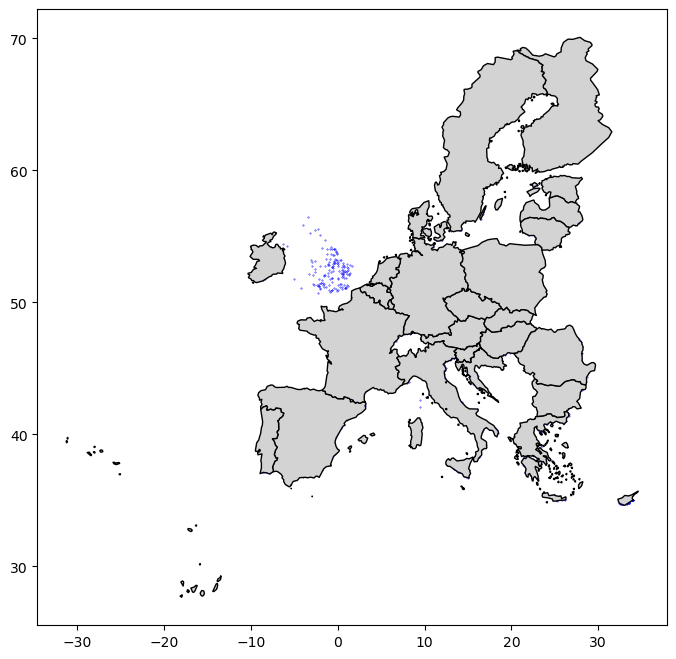

In [72]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

In [73]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	transformed_gdf = data_gdf[data_gdf['pH_CaCl2'] > 6]
	fig, ax = plt.subplots(figsize=(10, 8))
	transformed_gdf.plot(ax=ax, color='blue', markersize=0.1)
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	plt.show()


In [74]:
exec_solution(solution_function_string)

# 2. query

In [75]:
objective = "Plot all the points with LC0_Desc=Woodland in Europe. Save the result as a png. Use geopandas."

2025-01-29 22:37:55,420 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf.geometry.apply(lambda x: x.intersects(gpd.points_from_xy(x=0, y=0))))].copy()
```

This code filters the GeoDataFrame `data_gdf` to only include points where LC0_Desc is Woodland and intersects with a point at coordinates (0, 0). The result is stored in the new GeoDataFrame `transformed_gdf`.
2025-01-29 22:37:55,424 - Error while running transform query: 'data' should be array of geometry objects. Use from_shapely, from_wkb, from_wkt functions to construct a GeometryArray.
2025-01-29 22:38:06,667 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland'].copy()
```

This code snippet uses the `geopandas` library to filter the GeoDataFrame based on the LC0_Desc column and stores the result in a new GeoDataFrame called transformed_gdf

map


2025-01-29 22:38:22,159 - Query finished successfully, response: 
```python
import geopandas as gpd

fig, ax = plt.subplots(figsize=(10, 6))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
transformed_gdf.loc[transformed_gdf['LC0_Desc'] == 'Woodland'].plot(ax=ax, marker='o', markersize=2, color='green')
plt.title('Points with LC0_Desc = Woodland in Europe')
plt.savefig('woodland_points_in_europe.png')
```


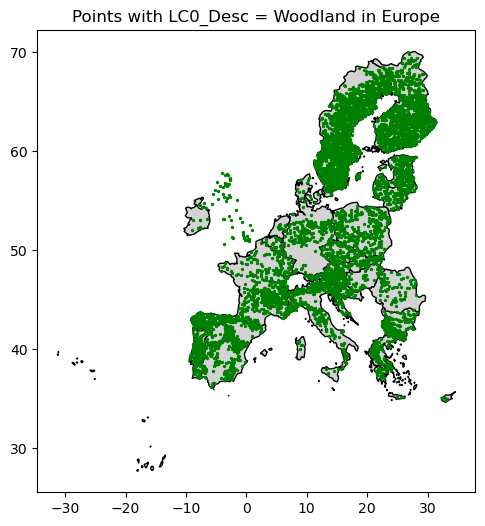

In [76]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

In [77]:
print(solution_function_string)

def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	transformed_gdf = data_gdf[data_gdf['LC0_Desc'] == 'Woodland'].copy()
	fig, ax = plt.subplots(figsize=(10, 6))
	europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
	transformed_gdf.loc[transformed_gdf['LC0_Desc'] == 'Woodland'].plot(ax=ax, marker='o', markersize=2, color='green')
	plt.title('Points with LC0_Desc = Woodland in Europe')
	plt.savefig('woodland_points_in_europe.png')


In [85]:
exec_solution(solution_function_string)

# 3. query

In [86]:
objective = "Plot all the points with LC0_Desc=Woodland & pH<6 in Europe. Save the result as a png. Use geopandas."

In [87]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

2025-01-29 22:41:36,369 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & 
                           (data_gdf['pH_CaCl2'] < 6) &
                           (data_gdf.geometry.intersects(gpd.points_from_xy(data_gdf['TH_LAT'], data_gdf['TH_LONG']))]
```
2025-01-29 22:41:36,370 - Error while running transform query: closing parenthesis ']' does not match opening parenthesis '(' (<string>, line 4)
2025-01-29 22:41:47,485 - Query finished successfully, response: 
```python
transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Woodland') & (data_gdf['pH_CaCl2'] < 6) &
                          (data_gdf.geometry.intersects(gpd.points_from_xy(data_gdf['TH_LAT'], data_gdf['TH_LONG']))]
```
2025-01-29 22:41:47,487 - Error while running transform query: closing parenthesis ']' does not match opening parenthesis '(' (<string>, line 3)
2025-01-29 22:41:58,512 - Query finished successfully, response: 
```p

ValueError: Error while running transform query: closing parenthesis ']' does not match opening parenthesis '(' (<string>, line 3)

In [ ]:
print(solution_function_string)

In [92]:
exec_solution(solution_function_string)

# 4. query

In [97]:
objective = "Perform KMeans clustering on the TH_LAT and TH_LONG data to identify 3 clusters and plot them on a map. Save it as a png."

In [98]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

2025-01-29 22:45:01,942 - Query finished successfully, response: 
```python
import pandas as pd

data_gdf = ...  # your GeoDataFrame object

# Filter data for TH_LAT and TH_LONG columns with values between -80 and 40 degrees latitude and longitude between -180 and 180 degrees
filtered_data_gdf = data_gdf[(data_gdf['TH_LAT'] >= -80) & (data_gdf['TH_LAT'] <= 40) &
                            (data_gdf['TH_LONG'] >= -180) & (data_gdf['TH_LONG'] <= 180)]

# Select only TH_LAT and TH_LONG columns
filtered_data_gdf = filtered_data_gdf[['TH_LAT', 'TH_LONG']]

# Perform KMeans clustering with k=3
kmeans = KMeans(n_clusters=3)
transformed_data_gdf = pd.DataFrame(kmeans.fit_transform(filtered_data_gdf), columns=['Cluster'])

# Add cluster labels to the original GeoDataFrame
data_gdf['Cluster'] = transformed_data_gdf['Cluster']
```
2025-01-29 22:45:01,944 - Error while running transform query: 'ellipsis' object is not subscriptable
2025-01-29 22:45:35,505 - Query finished successfully, response: 

KeyboardInterrupt: 

In [ ]:
print(solution_function_string)

In [ ]:
exec_solution(solution_function_string)

# 5. query

In [99]:
objective = "Create a map with markers for all locations where 'K' is above its median value, in Europe. Use geopandas. Save the result as a png."

In [100]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=10
)

2025-01-29 22:46:27,187 - Query finished successfully, response: 
```python
import geopandas as gpd

data_gdf = ...  # your GeoDataFrame object

# Filter for Europe and K > median(K)
transformed_gdf = data_gdf[(data_gdf['geometry'].intersects(gpd.points_from_xy(data_gdf['TH_LAT'], data_gdf['TH_LONG'])) & 
                           (data_gdf['K'] > data_gdf['K'].median())]

# Create a map with markers for the filtered locations
import folium

m = folium.Map(location=[50, 0], zoom_start=5)
folium.Marker(
    location=[transformed_gdf.geometry.y.min(), transformed_gdf.geometry.x.min()],
    popup='Minimum K in Europe',
).add_to(m)

for i, row in transformed_gdf.iterrows():
    folium.Marker(
        location=[row['TH_LAT'], row['TH_LONG']],
        popup=f'K: {row["K"]}, Latitude: {row["TH_LAT"]}, Longitude: {row["TH_LONG"]}',
    ).add_to(m)

m.save('map.html')
```
2025-01-29 22:46:27,188 - Error while running transform query: closing parenthesis ']' does not match opening parenthesis '

KeyboardInterrupt: 

In [ ]:
transformed_gdf = data_gdf[data_gdf['geometry'].intersects(gpd.points_from_xy(data_gdf['TH_LAT'], data_gdf['TH_LONG'])) & 
                            (data_gdf['K'] > data_gdf['K'].median())]

In [ ]:
print(solution_function_string)

In [ ]:
exec_solution(solution_function_string)

# 6. query

In [35]:
objective = "Generate a heatmap where each point is weighted by 'pH_CaCl2', in Europe. Don't merge these shapefiles just plot them. Use geopandas. Save the result as a png."

2025-01-29 22:13:17,449 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf.copy()
transformed_gdf['pH_CaCl2_weight'] = transformed_gdf.apply(lambda row: row['pH_CaCl2'], axis=1)
transformed_gdf.loc[transformed_gdf.geometry.type == 'Point', 'geometry'] = gpd.GeoSeries(transformed_gdf.geometry, crs='EPSG:4326')
```

Note that this code will create a new column `pH_CaCl2_weight` with the same values as the original `pH_CaCl2` column. It also converts all point geometries to WGS84 (EPSG:4326) CRS, which is necessary for plotting heatmaps.

Please note that you need to replace 'data_gdf' with your actual GeoDataFrame object.
2025-01-29 22:13:19,443 - Query finished successfully, response: 
map
2025-01-29 22:13:31,089 - Query finished successfully, response: 
```python
import geopandas as gpd

fig, ax = plt.subplots(figsize=(10, 8))
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')
transformed_gdf.plot(ax=ax, column='pH_CaCl2_we

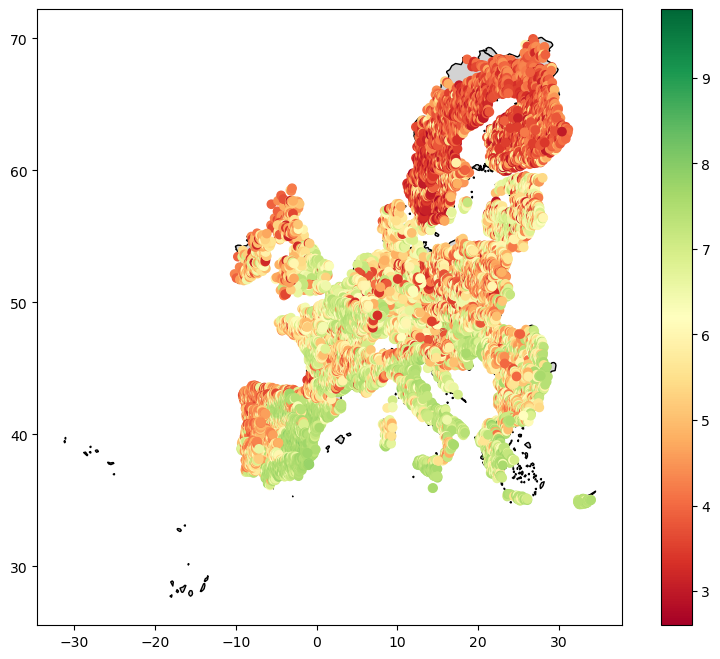

In [36]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

In [ ]:
print(solution_function_string)

In [ ]:
exec_solution(solution_function_string)

# 7. query

In [37]:
objective = "Create a map with markers for points where 'K' is in the top 10 percentile, in Europe. Don't merge these shapefiles just plot them. Use geopandas. Save the result as a png."

In [39]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

2025-01-29 22:17:00,734 - Query finished successfully, response: 
```python
import geopandas as gpd

# Filter points where 'K' is in the top 10 percentile and geometry.intersects(europe_gdf)
europe_gdf = data_gdf[(data_gdf['K'] >= data_gdf['K'].quantile(0.9)] & 
                      (data_gdf.geometry.intersects(europe_gdf.geometry))]

# Create a new GeoDataFrame with the filtered points
transformed_gdf = gpd.GeoDataFrame(
    europe_gdf[['geometry', 'POINTID', 'K']].copy(),
    geometry='geometry'
)
```
2025-01-29 22:17:00,735 - Error while running transform query: closing parenthesis ']' does not match opening parenthesis '(' (<string>, line 3)
2025-01-29 22:17:15,457 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[(data_gdf['K'] >= data_gdf['K'].quantile(0.9)] & (data_gdf.geometry.intersects(europe_gdf.geometry))]
geometry_column_name = 'geometry'
transformed_gdf = gpd.GeoDataFrame(
    europe_gdf[['geometry', 'POINTID', 'K']]

ValueError: Error while running transform query: closing parenthesis ']' does not match opening parenthesis '(' (<string>, line 2)

In [ ]:
print(solution_function_string)

In [ ]:
exec_solution(solution_function_string)

# 8. query

In [42]:
objective = "Plot group of points with 'pH_H2O'>5 and 'pH_H2O'<5 in Europe."

2025-01-29 22:19:52,451 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[(data_gdf['pH_H2O'] > 5) & (data_gdf['pH_H2O'] < 5)]
```

This code filters the GeoDataFrame `data_gdf` based on the conditions 'pH_H2O'>5 and 'pH_H2O'<5, resulting in a new GeoDataFrame called `transformed_gdf`.
2025-01-29 22:19:54,165 - Query finished successfully, response: 
map
2025-01-29 22:20:07,670 - Query finished successfully, response: 
```python
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))
transformed_gdf.plot(ax=ax, color='blue', marker='o')
europe_gdf.plot(ax=ax, edgecolor='black', color='lightgray')

plt.show()
```

Note: This will create a simple scatter plot of the points from transformed_gdf on top of the map of Europe. The 'pH_H2O' values are used to determine the marker colors and sizes for each point.
2025-01-29 22:20:07,685 - Error while running visualize query: aspect must be finite and positive 
2025-01-29 22:

ValueError: Error while running visualize query: aspect must be finite and positive 

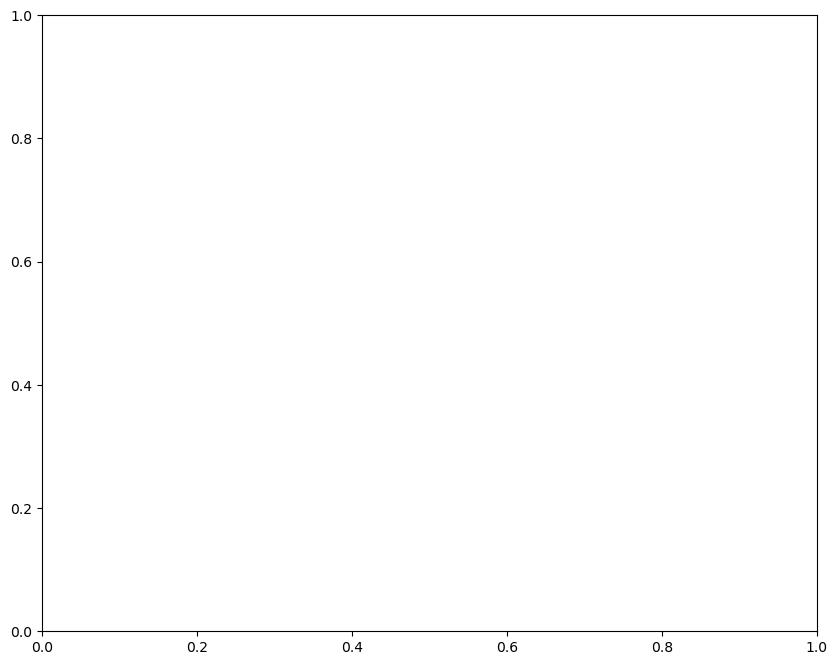

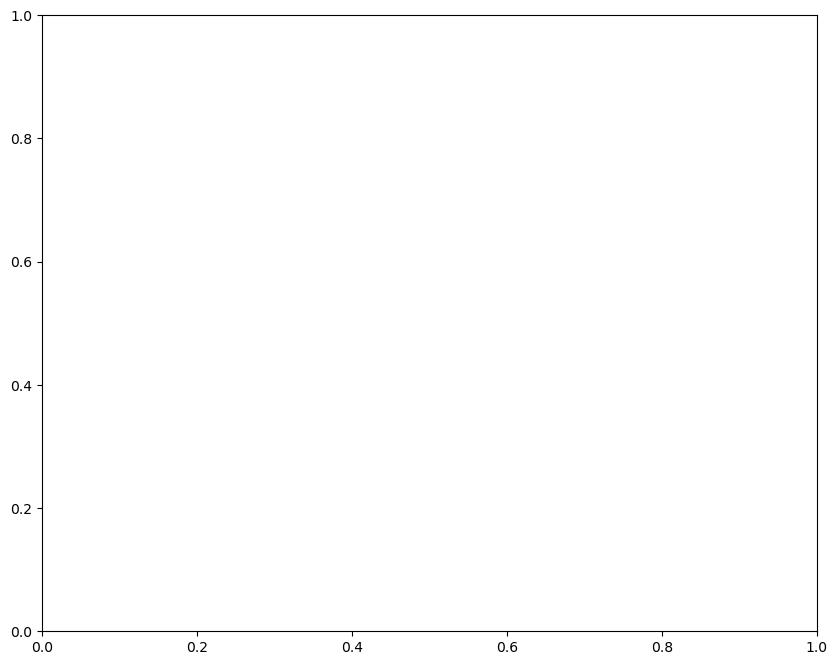

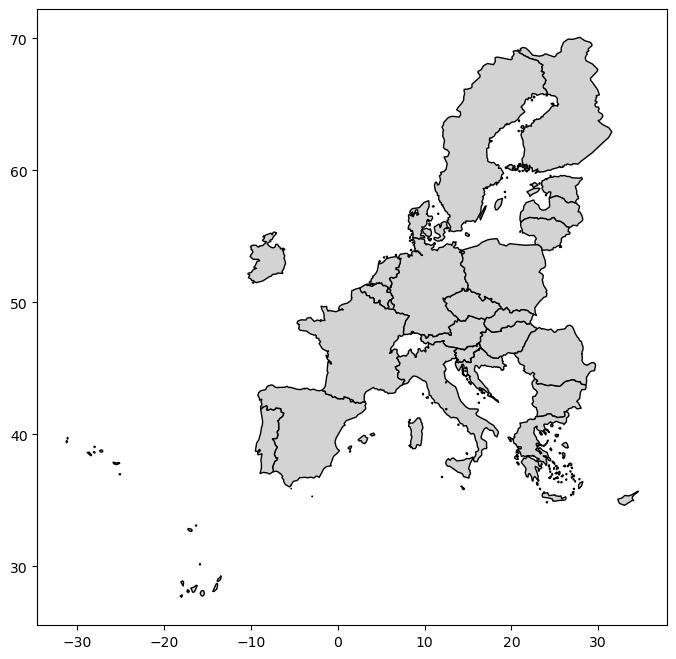

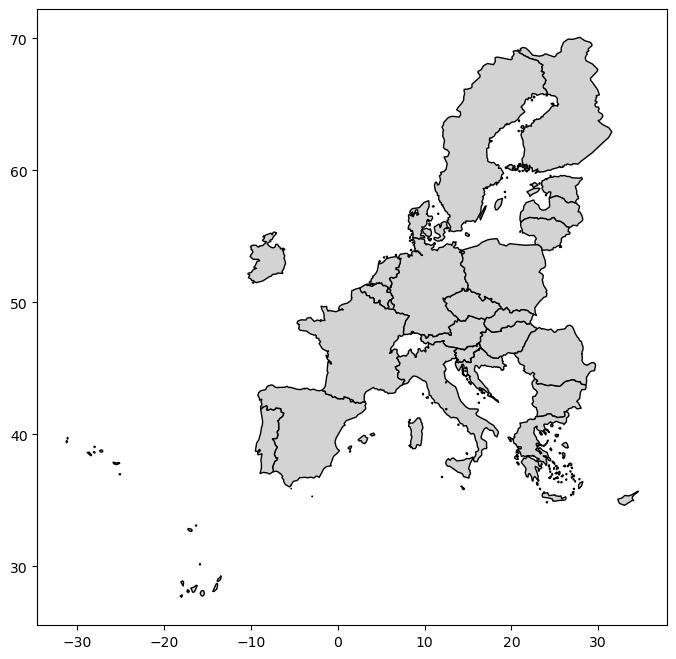

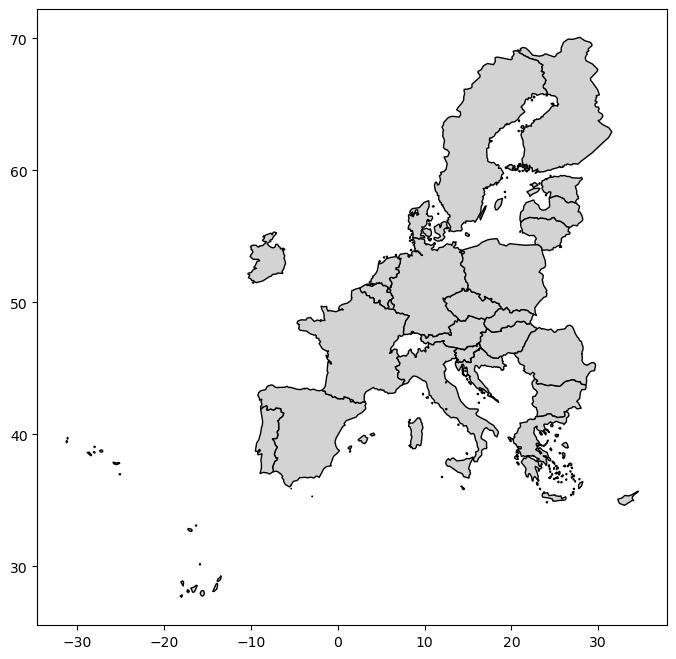

In [43]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

In [ ]:
print(solution_function_string)

In [ ]:
exec_solution(solution_function_string)

# 9. query

In [48]:
objective = "Create a map displaying the distribution of soil types ('LC0_Desc') across Europe. Each soil type should be represented by a different color. Use geopandas and save the map as a png."

In [50]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=5
)

query_type: QueryType.TRANSFORM


2025-01-29 22:25:34,143 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = (
    gpd.GeoDataFrame(
        data_df=gdf,
        geometry=gdf['geometry']
    )
)
```

Note: The above code does not perform any transformations on the GeoDataFrame. It simply creates a new GeoDataFrame with the same data and geometry, which is essentially identical to the original `gdf`.
2025-01-29 22:25:34,144 - Error while running transform query: name 'gdf' is not defined


query_type: QueryType.TRANSFORM_ERROR


2025-01-29 22:25:55,950 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = (
    gpd.GeoDataFrame(
        data_df=data_gdf,
        geometry=gpd.points_from_xy(data_gdf['geometry'].x, data_gdf['geometry'].y)
    )
)

# Map soil types to colors
soil_types = {
    'Clay': '#ff0000',
    'Silt': '#ffff00',
    'Sand': '#00ff00'
}

transformed_gdf['LC0_Desc'] = transformed_gdf['LC0_Desc'].map(soil_types)
```

Note: This code assumes that the GeoDataFrame `data_gdf` has a column named 'geometry' with shapefile data. The points are created from this geometry and then mapped to different colors based on soil types.
2025-01-29 22:25:55,957 - Error while running transform query: DataFrame.__init__() got an unexpected keyword argument 'data_df'


query_type: QueryType.TRANSFORM_ERROR


...

query_type: QueryType.TRANSFORM_ERROR


2025-01-29 22:26:31,323 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = (
    gpd.GeoDataFrame(
        data_gdf,
        geometry=gpd.points_from_xy(data_gdf['geometry'].x, data_gdf['geometry'].y)
    )
)

soil_types = {
    'Clay': '#ff0000',
    'Silt': '#ffff00',
    'Sand': '#00ff00'
}

transformed_gdf['LC0_Desc'] = transformed_gdf.apply(
    lambda row: soil_types[row.LC0_Desc],
    axis=1
)
```
2025-01-29 22:26:31,365 - Error while running transform query: 'Woodland'


query_type: QueryType.TRANSFORM_ERROR


2025-01-29 22:26:47,173 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = (
    gpd.GeoDataFrame(
        data_gdf,
        geometry=gpd.points_from_xy(data_gdf['geometry'].x, data_gdf['geometry'].y)
    )
)

soil_types = {
    'Clay': '#ff0000',
    'Silt': '#ffff00',
    'Sand': '#00ff00'
}

transformed_gdf['LC0_Desc'] = transformed_gdf.apply(
    lambda row: soil_types[row.LC0_Desc],
    axis=1
)
```
2025-01-29 22:26:47,257 - Error while running transform query: 'Woodland'


ValueError: Error while running transform query: 'Woodland'

In [ ]:
print(solution_function_string)

In [ ]:
exec_solution(solution_function_string)

# 10. query

In [51]:
objective = "Plot all the LC0_Desc='Grassland' and LC0_Desc='Woodland' points where 'OC'>20. Use geopandas and save the map as a png."

In [52]:
solution_function_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    data_gdf_description=data_gdf_description,
    europe_gdf=europe_gdf,
    europe_gdf_description=europe_gdf_description,
    retry_count=7
)

2025-01-29 22:28:11,259 - Query finished successfully, response: 
```python
import geopandas as gpd

transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')] & 
                          (data_gdf['OC'] > 20)
```

This code filters the GeoDataFrame `data_gdf` to include only rows where the LC0_Desc is either 'Grassland' or 'Woodland', and the OC value is greater than 20. The result is stored in a new GeoDataFrame called `transformed_gdf`.
2025-01-29 22:28:11,261 - Error while running transform query: invalid syntax (<string>, line 2)
2025-01-29 22:28:22,373 - Query finished successfully, response: 
```python
transformed_gdf = data_gdf[(data_gdf['LC0_Desc'] == 'Grassland') | (data_gdf['LC0_Desc'] == 'Woodland')] & 
                         (data_gdf['OC'] > 20)
```

This code directly transforms the GeoDataFrame `data_gdf` according to your requirements.
2025-01-29 22:28:22,374 - Error while running transform query: invalid syntax (<string

ValueError: Error while running transform query: 'OC_30 cm'

In [ ]:
solution_function_string

In [ ]:
exec_solution(solution_function_string)

In [ ]:
type_query = QueryProvider.get_query(QueryType.TYPE, objective=objective)
logging.log(logging.INFO, "Running type query")
type_response = client_instructor.query(type_query)

In [281]:
transform_query = QueryProvider.get_query(QueryType.TRANSFORM, objective=objective, data_gdf_description=data_gdf_description)
transform_response = client_instructor.query(transform_query)

In [282]:
transform_code = extract_python_code(transform_response)
cleaned_transform_code = clean_python_code(transform_code)
description_extraction_function_code = get_description_extraction_function_string(cleaned_transform_code)
local_scope = {}
exec(description_extraction_function_code, globals(), local_scope)
intermediate_data_description = local_scope['get_transformed_data_description'](data_gdf)

In [ ]:
print(cleaned_transform_code)

In [284]:
if "map" in type_response.lower():
    visualization_query = QueryProvider.get_query(QueryType.VISUALIZE_MAP, objective=objective, intermediate_data_description=intermediate_data_description)
elif "graph" in type_response.lower():
    visualization_query = QueryProvider.get_query(QueryType.VISUALIZE_GRAPH, objective=objective, intermediate_data_description=intermediate_data_description)
elif "print" in type_response.lower():
    visualization_query = QueryProvider.get_query(QueryType.VISUALIZE_PRINT, objective=objective, intermediate_data_description=intermediate_data_description)
visualization_response = client_instructor.query(visualization_query)

In [ ]:
visualize_code = extract_python_code(visualization_response)
cleaned_visualize_code = clean_python_code(visualize_code)
solution_function_string = get_solution_function_string(cleaned_transform_code, cleaned_visualize_code)
local_scope = {}
exec(solution_function_string, globals(), local_scope)
local_scope['solve'](data_gdf, europe_gdf)

In [ ]:
print(solution_function_string)

In [255]:
def solve(data_gdf: gpd.GeoDataFrame, europe_gdf: gpd.GeoDataFrame):
	# Calculate the 10th percentile of 'K'
	k_10_percentile = stats.percentileofscore(data_gdf['K'], 90)
	# Filter points where 'K' is in the top 10 percentile
	transformed_gdf = data_gdf[data_gdf['K'] >= k_10_percentile]
	# Assuming europe_gdf is already loaded and contains Europe's map data
	europe_gdf.plot(edgecolor='black', color='lightgray')
	transformed_gdf.plot(markersize=5, column='K', legend=True, cmap='coolwarm')
	plt.title('Map of Points with K in the Top 10 Percentile in Europe')
	plt.savefig('top_10_percentile_k.png')

In [ ]:
solve(data_gdf, europe_gdf)

In [ ]:
initial_query = QueryProvider.get_query(query_type=QueryType.INITIAL, 
                                        objective=objective, 
                                        data_gdf_description=data_description)
logging.log(logging.INFO, "Running initial query")
response = client_instructor.query(initial_query)

logging.log(logging.INFO, f"Initial query finished successfully, response: \n{response}")

logging.log(logging.INFO, "Started parsing response")
try:
    parsed_response = extract_json(response)
    transform_instructions = parsed_response["transform"]
    visualize_instructions = parsed_response["visualize"]
    # intermediate_data_description = parsed_response["column_definitions"]
except Exception as e:
    raise ValueError("Parsed response is not in json format or does not contain transform, visualize, or column_definitions keys.")
logging.log(logging.INFO, "Parsing successful")

logging.log(logging.INFO, "Running transform query")
transform_query = QueryProvider.get_query(query_type=QueryType.TRANSFORM,
                                        objective=transform_instructions,
                                        data_gdf_description=data_description,
                                        functions=transform_functions,)
transform_response = client_coder.query(transform_query)

logging.log(logging.INFO, f"Transform query finished successfully, response: \n{extract_python_code(transform_response)}")

try:
    transform_code = extract_python_code(transform_response)
    cleaned_transform_code = clean_python_code(transform_code)
    description_extraction_function_code = get_description_extraction_function_string(cleaned_transform_code)
    local_scope = {}
    exec(description_extraction_function_code, globals(), local_scope)
    intermediate_data_description = local_scope['get_transformed_data_description'](data_gdf)
except Exception as e:
    raise ValueError(f"Error while running transform query: {e}")

logging.log(logging.INFO, "Running visualize query")

visualize_query = QueryProvider.get_query(query_type=QueryType.VISUALIZE,
                                            objective=visualize_instructions,
                                            europe_gdf_description=europe_gdf_description,
                                            intermediate_data_description=intermediate_data_description,
                                            functions=visualize_functions
                                            )

visualize_response = client_coder.query(visualize_query)
logging.log(logging.INFO, f"Visualize query finished successfully, response: \n{extract_python_code(visualize_response)}")

try:
    visualize_code = extract_python_code(visualize_response)
    cleaned_visualize_code = clean_python_code(visualize_code)
    solution_function_string = get_solution_function_string(cleaned_transform_code, cleaned_visualize_code)
    local_scope = {}
    exec(solution_function_string, globals(), local_scope)
    local_scope['solve'](data_gdf, europe_gdf)
except Exception as e:
    raise ValueError(f"Error while running visualize query: {e}")

In [ ]:
print(solution_function_string)

In [ ]:
for query_type in query_types:
    query_count = len(os.listdir(BASE_QUERY_DIR + query_type))
    print(f"Processing {query_count} {query_type} queries")
    os.makedirs(f"{BASE_GENERATED_DIR}{query_type}", exist_ok=True)
    os.makedirs(f"{BASE_METRICS_DIR}{model_id}/{query_type}", exist_ok=True)
    
    for file in os.listdir(BASE_QUERY_DIR + query_type):
        query_index = int(file.split('.')[0])
        
        query = open(f"{BASE_QUERY_DIR}{query_type}/{file}", 'r').read()
        correct_result = open(f"{BASE_CORRECT_RESULT_DIR}{query_type}/{file}", 'r').read()
        
        generated_result = None
        for i in range(3):
            try:
                generated_result = solution_code_string = run_pipeline(
                    objective=query,
                    client_instructor=client_instructor,
                    client_coder=client_coder,
                    data_gdf=data_gdf,
                    europe_gdf=europe_gdf,
                    transform_functions=transform_functions,
                    visualize_functions=visualize_functions,
                )
                break
            except Exception as e:
                print(f"Error: {e}")
        
        if not generated_result is None:
            open(f"{BASE_GENERATED_DIR}{query_type}/{query_index}.txt", 'w').write(generated_result)
            
            metrics = evaluate_metrics(correct_result, generated_result)
            metrics.MODEL_ID = model_id
            with open(f"{BASE_METRICS_DIR}{model_id}/{query_type}/{query_index}.json", 'w') as f:
                json.dump(metrics.model_dump(), f, indent=4)

In [ ]:
solution_code_string = run_pipeline(
    objective=objective,
    client_instructor=client_instructor,
    client_coder=client_coder,
    data_gdf=data_gdf,
    europe_gdf=europe_gdf,
    transform_functions=transform_functions,
    visualize_functions=visualize_functions,
)